In [ ]:
import numpy as np
import pandas as pd

In [ ]:
insurance_data = pd.read_csv("insurance (1).csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
insurance_data['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
insurance_data['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
insurance_data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
insurance_data.replace({'female':0,'male':1}, inplace=True)
insurance_data.replace({'yes':1,'no':0},inplace=True)

In [ ]:
insurance_data = pd.get_dummies(insurance_data, columns=['region'])
insurance_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,False,True,False,False
1334,18,0,31.920,0,0,2205.98080,True,False,False,False
1335,18,0,36.850,0,0,1629.83350,False,False,True,False
1336,21,0,25.800,0,0,2007.94500,False,False,False,True


In [ ]:
insurance_data[['region_northeast','region_northwest','region_southeast','region_southwest']] = insurance_data[['region_northeast','region_northwest','region_southeast','region_southwest']].replace({True:1,False:0})

In [ ]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northeast  1338 non-null   int64  
 7   region_northwest  1338 non-null   int64  
 8   region_southeast  1338 non-null   int64  
 9   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 104.7 KB


In [ ]:
insurance_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


## Feature Engineering

In [ ]:
X = insurance_data.drop('charges',axis=1)
y = insurance_data['charges']

In [ ]:
X

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,0,1,0,0
1334,18,0,31.920,0,0,1,0,0,0
1335,18,0,36.850,0,0,0,0,1,0
1336,21,0,25.800,0,0,0,0,0,1


In [ ]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [ ]:
# Train and Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=110)
print("X_train :",len(X_train))
print("X_test :",len(X_test))
print("y_train  :",len(y_train))
print("y_test :",len(y_test))

X_train : 936
X_test : 402
y_train  : 936
y_test : 402


# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Co-efficient
for idx,col_name in enumerate(X_train.columns):
    print("The Cofficient for {} is {}".format(col_name,regression_model.coef_[idx]))

The Cofficient for age is 254.34989233141533
The Cofficient for sex is 114.24917508272705
The Cofficient for bmi is 323.21757785397745
The Cofficient for children is 346.08583713748806
The Cofficient for smoker is 23458.798712258802
The Cofficient for region_northeast is 387.8850548185206
The Cofficient for region_northwest is 508.2072537290515
The Cofficient for region_southeast is -470.54547351658096
The Cofficient for region_southwest is -425.5468350309921


In [ ]:
# Intercept
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -11814.66298427387


In [ ]:
# Score
score = regression_model.score(X_train,y_train)
print("Score R2",score)

Score R2 0.7351938380209204


## Error

In [ ]:
y_pred = regression_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

# mean_squared_error
mse = mean_squared_error(y_test,y_pred)

#mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)

# root of mean squared error
rmse = np.sqrt(mse)

print("mean_squared_error",mse)
print("mean_absolute_error",mae)
print("Root of mean Squared error",rmse)

mean_squared_error 34642172.49216432
mean_absolute_error 4198.184356066575
Root of mean Squared error 5885.760145653603


## Adjusted  R2

In [ ]:
adjustedr2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2:", adjustedr2)

Adjusted R2: 0.7291141047101762


## OLS Summary

In [ ]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     321.7
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          2.25e-261
Time:                        06:02:07   Log-Likelihood:                -9489.3
No. Observations:                 936   AIC:                         1.900e+04
Df Residuals:                     927   BIC:                         1.904e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
age                254.3499     14.642  

# DESICION TREE  REGRESSION

In [ ]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Hyperparameter Tuning

In [ ]:
param = {'criterion':['squared_error','friedman_mse','abbsolute_error'],
        'splitter':['best','random'],
        'max_depth':[1,2,3,4,5,10,15,2,25],
        'max_features':['auto','sqrt','log2']}
param

{'criterion': ['squared_error', 'friedman_mse', 'abbsolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 10, 15, 2, 25],
 'max_features': ['auto', 'sqrt', 'log2']}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
regressor = DecisionTreeRegressor()

In [ ]:
grid = GridSearchCV(regressor, param_grid=param, cv=5, scoring='neg_mean_squared_error')

In [ ]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [ ]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
print("r2_score :",r2_score(y_test,y_pred))
print('mean_absolute_error :',mean_absolute_error(y_test,y_pred))
print("mean_squared_error :",mean_squared_error(y_test,y_pred))

r2_score : 0.7811390417983538
mean_absolute_error : 4198.184356066575
mean_squared_error : 34642172.49216432


In [ ]:
selectmodel = DecisionTreeRegressor(
    criterion='squared_error',max_depth=5,  max_features='sqrt',
    splitter='best'
)
selectmodel.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5330188679245284, 0.9166666666666666, 'x[3] <= 1.5\nsquared_error = 141413080.17\nsamples = 936\nvalue = 13108.74'),
 Text(0.28773584905660377, 0.75, 'x[0] <= 42.5\nsquared_error = 141878524.01\nsamples = 634\nvalue = 12552.424'),
 Text(0.41037735849056606, 0.8333333333333333, 'True  '),
 Text(0.1509433962264151, 0.5833333333333334, 'x[6] <= 0.5\nsquared_error = 124743831.292\nsamples = 367\nvalue = 9484.53'),
 Text(0.07547169811320754, 0.4166666666666667, 'x[4] <= 0.5\nsquared_error = 129359865.484\nsamples = 282\nvalue = 9997.631'),
 Text(0.03773584905660377, 0.25, 'x[0] <= 23.5\nsquared_error = 20731603.815\nsamples = 216\nvalue = 4739.991'),
 Text(0.018867924528301886, 0.08333333333333333, 'squared_error = 14405896.619\nsamples = 81\nvalue = 2828.029'),
 Text(0.05660377358490566, 0.08333333333333333, 'squared_error = 21017651.985\nsamples = 135\nvalue = 5887.169'),
 Text(0.11320754716981132, 0.25, 'x[0] <= 37.5\nsquared_error = 98328642.319\nsamples = 66\nvalue = 27204.45')

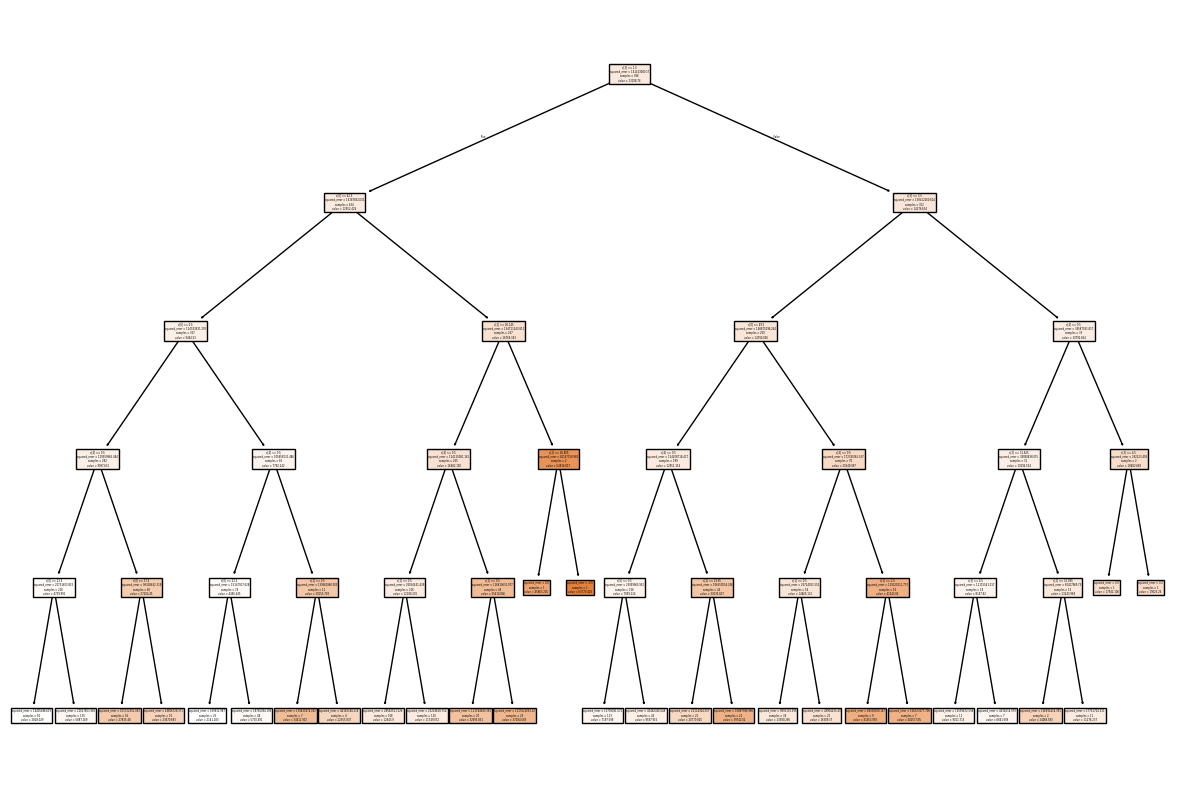

In [ ]:
# Vizualize the decision tree
from sklearn import  tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
tree.plot_tree(selectmodel,  filled=True)

# RANDOM FOREST  REGRESSOR

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# create a function to avalute model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true,predicted)
    return mae, rmse, r2_square

In [ ]:
# begining model training

models = {"Linear Regression": LinearRegression(),
         "Lasso": Lasso(),
         "Ridge": Ridge(),
         "K-Neighbors Regressor": KNeighborsRegressor(),
         "Desicion Tree": DecisionTreeRegressor(),
         "Random Forest Regressor": RandomForestRegressor()}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) #train  model

    #make Predicitions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae,  model_test_rmse,  model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model Perfromance for Training set')
    print("-Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("-Mean Absolute Error : {:.4f}".format(model_train_mae))
    print("-R2  Score : {:.4f}".format(model_train_r2))

    print('------------------------------------------------')

    print('model Perfromance for  test set')
    print("- Root Mean Squared  Error : {:.4f}".format(model_test_rmse))
    print("- Mean Squared Error : {:.4f}".format(model_test_mae))
    print("-R2 Score : {:.4f}".format(model_train_r2))

    print('='*35)
    print('\n')

Linear Regression
Model Perfromance for Training set
-Root Mean Squared Error : 6119.3999
-Mean Absolute Error : 4190.6415
-R2  Score : 0.7352
------------------------------------------------
model Perfromance for  test set
- Root Mean Squared  Error : 5885.7601
- Mean Squared Error : 4198.1844
-R2 Score : 0.7352


Lasso
Model Perfromance for Training set
-Root Mean Squared Error : 6119.4021
-Mean Absolute Error : 4190.9165
-R2  Score : 0.7352
------------------------------------------------
model Perfromance for  test set
- Root Mean Squared  Error : 5885.8694
- Mean Squared Error : 4198.4690
-R2 Score : 0.7352


Ridge
Model Perfromance for Training set
-Root Mean Squared Error : 6119.7181
-Mean Absolute Error : 4201.9209
-R2  Score : 0.7352
------------------------------------------------
model Perfromance for  test set
- Root Mean Squared  Error : 5891.7155
- Mean Squared Error : 4212.5138
-R2 Score : 0.7352


K-Neighbors Regressor
Model Perfromance for Training set
-Root Mean Squar

## Intialize few parameter for hyperparamter tuning

In [ ]:
knn_params = {"n_neighbors": [2,3,10,20,40,50]}
rf_params = {"max_depth": [5,8,15, None, 10],
            "max_features": [5,7,"auto",8],
            "min_samples_split": [2,8,15,20],
            "n_estimators": [100,200,500,1000]}

In [ ]:
# model list for Hyperparameter turning
randomcv_models = [('KNN', KNeighborsRegressor(), knn_params),
                  ("RF", RandomForestRegressor(), rf_params)]

In [ ]:
##Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for KNN -------------------
{'n_neighbors': 20}
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 15, 'max_features': 7, 'max_depth': 5}


In [ ]:
# Retraining the models with best parameters

models={
    "Random Forest Regressor": RandomForestRegressor(n_estimators=500, min_samples_split=15, max_features=7, max_depth=5),
    "K-Neighbors Regressor": KNeighborsRegressor (n_neighbors=20)
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # train model

    # MAke predicitiond
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('MOdel Performance for Training set')
    print("-  Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("- Mean absolute error : {:.4f}".format(model_train_mae))
    print("- R2 Score : {:.4f}".format(model_train_r2))

    print('-----------------------------------------------------')

    print("Model Performance for Teseting set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean absolute error : {:.4f}".format(model_test_mae))
    print("-r2 Score: {:.4f}".format(model_test_r2))

    print('='*35)
    print('\n')

Random Forest Regressor
MOdel Performance for Training set
-  Root Mean Squared Error : 4131.1743
- Mean absolute error : 2366.7375
- R2 Score : 0.8793
-----------------------------------------------------
Model Performance for Teseting set
- Root Mean Squared Error: 4236.6561
- Mean absolute error : 2379.7565
-r2 Score: 0.8866


K-Neighbors Regressor
MOdel Performance for Training set
-  Root Mean Squared Error : 10612.4398
- Mean absolute error : 8022.0055
- R2 Score : 0.2036
-----------------------------------------------------
Model Performance for Teseting set
- Root Mean Squared Error: 11675.8139
- Mean absolute error : 9024.1841
-r2 Score: 0.1387




# KNN REFRESSOR

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
regressor = KNeighborsRegressor(n_neighbors=6, algorithm='auto')
regressor.fit(X_train, y_train)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
print("r2_score",r2_score(y_test, y_pred))
print("mean_absolute_error",mean_absolute_error(y_test, y_pred))
print("mean_squared_error",mean_squared_error(y_test, y_pred))

r2_score 0.7811390417983538
mean_absolute_error 4198.184356066575
mean_squared_error 34642172.49216432


## Gradient BBoosting in Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# create a function to evaluate model

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
# beginning the model training

models={
    "Linear regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "DesicionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Adaboosting Regressor": AdaBoostRegressor(),
    "Gradient boosting regressor": GradientBoostingRegressor ()

}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,  y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # evalualte Train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 =  evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model Selection  for Training Dataset')
    print("- Mean Absolute Error : {:.4f}".format(model_train_mae))
    print("- root of mean squared  error : {:.4f}".format(model_train_rmse))
    print("-r2_score : {:.4f}".format(model_train_r2))

    print('----------------------------------------------')

    print("Model Selection for Testing dataset")
    print("-mean absolute error : {:.4f}".format(model_test_mae))
    print("-root of mean squared error :  {:.4f}".format(model_test_rmse))
    print("r2_score : {:.4f}".format(model_test_r2))

    print("="*35)
    print("\n")

Linear regression
Model Selection  for Training Dataset
- Mean Absolute Error : 4190.6415
- root of mean squared  error : 6119.3999
-r2_score : 0.7352
----------------------------------------------
Model Selection for Testing dataset
-mean absolute error : 4198.1844
-root of mean squared error :  5885.7601
r2_score : 0.7811


Lasso
Model Selection  for Training Dataset
- Mean Absolute Error : 4190.9165
- root of mean squared  error : 6119.4021
-r2_score : 0.7352
----------------------------------------------
Model Selection for Testing dataset
-mean absolute error : 4198.4690
-root of mean squared error :  5885.8694
r2_score : 0.7811


Ridge
Model Selection  for Training Dataset
- Mean Absolute Error : 4201.9209
- root of mean squared  error : 6119.7181
-r2_score : 0.7352
----------------------------------------------
Model Selection for Testing dataset
-mean absolute error : 4212.5138
-root of mean squared error :  5891.7155
r2_score : 0.7807


DesicionTreeRegressor
Model Selection  f

In [ ]:
# intialize fe parameter for hypermeter tuning

rf_params = {
    "max_depth":[5,8,15,None,10],
    "max_features":[5,7,"auto",8],
    "min_samples_split":[2,8,15,20],
    "n_estimators":[100,200,500,1000]
}

gradient_params={
    "loss":['squared_error','huber','absolute_error'],
    "criterion":['friedman_mse', 'squared_error','mse'],
    "min_samples_split":[2,8,1511,20],
    "n_estimators":[100,200,500],
    "max_depth":[5,8,15,None,10]
}

In [ ]:
# model list form Hyperparamter Tuning
randomcv_models=[('RF',RandomForestRegressor(),rf_params),
                ('GradientBoost',GradientBoostingRegressor(),gradient_params)]

In [ ]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

model_param= {}
for name, model,  params in randomcv_models:
    random = RandomizedSearchCV(estimator=model, param_distributions=params,
                               n_iter=100,cv=3,verbose=2,n_jobs=-1)

    random.fit(X_train,  y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------------- Best Params for {model_name} ------------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------------- Best Params for RF ------------------------
{'n_estimators': 100, 'min_samples_split': 15, 'max_features': 7, 'max_depth': 5}
---------------------- Best Params for GradientBoost ------------------------
{'n_estimators': 100, 'min_samples_split': 20, 'max_depth': 5, 'loss': 'huber', 'criterion': 'friedman_mse'}


In [ ]:
# retraining the models with best parameters

models = {
    "Random Forest  Regressor":  RandomForestRegressor(n_estimators=100, min_samples_split=15, max_features=7,max_depth=5),
    "GradientBBoost Regressor": GradientBoostingRegressor(n_estimators=100,min_samples_split=20,max_depth=5,loss='huber',criterion='friedman_mse')
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # train the model

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse,  model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('MOdel Performance for Trainninng dataset')
    print("-root of mean  squared  error : {:.4f}".format(model_train_rmse))
    print("mean absolute  error : {:.4f}".format(model_train_mae))
    print("r2 score : {:.4f}".format(model_train_r2))

    print("----------------------------------------------------")

    print('Model Performance for Tetsing dataset')
    print("-  root of mean squared error : {:.4f}".format(model_test_rmse))
    print("mean absolute error : {:.4f}".format(model_test_mae))
    print("r2 Score : {:.4f}".format(model_test_r2))

    print("="*35)
    print("\n")


Random Forest  Regressor
MOdel Performance for Trainninng dataset
-root of mean  squared  error : 4123.2438
mean absolute  error : 2378.4376
r2 score : 0.8798
----------------------------------------------------
Model Performance for Tetsing dataset
-  root of mean squared error : 4247.4950
mean absolute error : 2418.7924
r2 Score : 0.8860


GradientBBoost Regressor
MOdel Performance for Trainninng dataset
-root of mean  squared  error : 3869.0857
mean absolute  error : 1377.6113
r2 score : 0.8941
----------------------------------------------------
Model Performance for Tetsing dataset
-  root of mean squared error : 4231.3140
mean absolute error : 1708.6806
r2 Score : 0.8869




## THANK YOU